# Experiment Tracking with MLflow and the Case-Study Registry

**Chapter 26: MLOps and Governance**
**Docker image**: `ml4t`
**Book Reference**: Chapter 26, Sections 26.1, 26.2, 26.4, 26.6
**Prerequisites**: Basic model evaluation, validation workflows, and Chapter 25 deployment verification.

**Learning Objectives**:
- Inspect the content-addressed case-study registry — schema, hashing, and
  reproducibility manifests — as a minimum viable experiment tracker.
- Reconstruct a searchable run catalog from `training_runs`,
  `prediction_sets`, and `backtest_runs`.
- Log catalog rows into a local MLflow tracking store (a capped sample, for
  speed) and use `search_runs` to confirm ranking parity for the logged runs.

This notebook connects two experiment-tracking approaches. The case-study
registry — a SQLite database backed by content-addressed artifact bundles —
already implements the run log requirements from Section 6.7: provenance,
configuration, metrics, artifacts, and decision gates.

MLflow provides a standard API (`log_params`, `log_metrics`, `search_runs`)
that automates the same workflow. The notebook first explores the registry
directly, then logs its runs into a local MLflow store and verifies that
rankings are identical — showing that the governance value comes from the
underlying discipline, not the specific tool. Sharpe logging, lineage
manifests, and explicit stage transitions are discussed in §26.6 prose but
stay outside the scope of this demo notebook.

In [1]:
"""Experiment Tracking with MLflow and the Case-Study Registry."""

'Experiment Tracking with MLflow and the Case-Study Registry.'

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = "fwd_ret_1d"
SECONDARY_LABEL = "fwd_ret_5d"

In [3]:
import json
import sqlite3
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
from IPython.display import display

warnings.filterwarnings("ignore")

from utils.paths import get_case_study_dir, get_output_dir
from utils.style import COLORS, FIGSIZE, add_message_title

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_PATH = CASE_DIR / "run_log" / "registry.db"
TRAINING_DIR = CASE_DIR / "run_log" / "training"
PREDICTIONS_DIR = CASE_DIR / "run_log" / "predictions"

print("Experiment Tracking with MLflow and the Case-Study Registry")
print("=" * 60)

Experiment Tracking with MLflow and the Case-Study Registry


## 1. The case-study registry — schema and design

Section 6.7 defined five non-negotiable categories for a run log: provenance,
data and evaluation protocol, configuration, artifacts, and decision gates.
The case study pipeline (Chapters 11–16) implemented these requirements in a
three-level entity model:

$$\text{training\_run} \to \text{prediction\_set} \to \text{backtest\_run}$$

Each level is identified by a deterministic hash of its canonical JSON spec.
The same config always produces the same hash, so re-running a pipeline
either overwrites the existing entry (idempotent) or confirms the result.

In [4]:
from case_studies.utils.registry import REGISTRY_SCHEMA_SQL, canonical_json, compute_hash

print("Registry schema (tables and indexes):")
for line in REGISTRY_SCHEMA_SQL.strip().split("\n"):
    stripped = line.strip()
    if stripped.startswith("CREATE TABLE") or stripped.startswith("CREATE INDEX"):
        print(f"  {stripped.split('(')[0]}")

Registry schema (tables and indexes):
  CREATE TABLE IF NOT EXISTS training_runs 
  CREATE INDEX IF NOT EXISTS idx_training_family_label ON training_runs
  CREATE INDEX IF NOT EXISTS idx_training_config_name ON training_runs
  CREATE TABLE IF NOT EXISTS prediction_sets 
  CREATE INDEX IF NOT EXISTS idx_pred_training ON prediction_sets
  CREATE INDEX IF NOT EXISTS idx_pred_split ON prediction_sets
  CREATE TABLE IF NOT EXISTS prediction_metrics 
  CREATE TABLE IF NOT EXISTS fold_metrics 
  CREATE INDEX IF NOT EXISTS idx_fold_metrics_pred ON fold_metrics
  CREATE TABLE IF NOT EXISTS backtest_runs 
  CREATE INDEX IF NOT EXISTS idx_backtest_pred ON backtest_runs
  CREATE INDEX IF NOT EXISTS idx_backtest_stage ON backtest_runs
  CREATE TABLE IF NOT EXISTS backtest_metrics 
  CREATE TABLE IF NOT EXISTS backtest_fold_metrics 
  CREATE INDEX IF NOT EXISTS idx_bt_fold_metrics ON backtest_fold_metrics
  CREATE TABLE IF NOT EXISTS causal_runs 
  CREATE INDEX IF NOT EXISTS idx_causal_label ON caus

In [5]:
# Content-addressed hashing: same config → same run ID
example_config = {
    "family": "gbm",
    "label": "fwd_ret_1d",
    "config_name": "leaves_31_mae",
    "seed": 42,
}
example_hash = compute_hash(canonical_json(example_config))
print(f"Config:  {canonical_json(example_config)}")
print(f"Hash:    {example_hash}")
print(f"Stable:  {example_hash == compute_hash(canonical_json(example_config))}")

Config:  {"config_name":"leaves_31_mae","family":"gbm","label":"fwd_ret_1d","seed":42}
Hash:    b7ca6f828792
Stable:  True


This is the same information MLflow stores in its tracking database — params,
metrics, artifact URIs, and run lineage. The sections below load the real
registry contents and then show how MLflow's standard API provides the same
queries.

## 2. Load the registry tables

The registry stores the essential experiment-tracking payload across five
tables: `training_runs`, `prediction_sets`, `prediction_metrics`,
`backtest_runs`, and `backtest_metrics`.

In [6]:
def query_table(query: str, params: tuple[object, ...] = ()) -> pd.DataFrame:
    with sqlite3.connect(REGISTRY_PATH) as conn:
        return pd.read_sql_query(query, conn, params=params)

In [7]:
training_runs = query_table(
    """
    SELECT training_hash, family, label, config_name, created_at, spec_json
    FROM training_runs
    WHERE label IN (?, ?)
    """,
    (PRIMARY_LABEL, SECONDARY_LABEL),
)

backtest_runs = query_table(
    """
    SELECT br.backtest_hash, br.prediction_hash, br.spec_json, br.created_at,
           tr.label, tr.family, tr.config_name
    FROM backtest_runs br
    JOIN prediction_sets ps ON br.prediction_hash = ps.prediction_hash
    JOIN training_runs tr ON ps.training_hash = tr.training_hash
    WHERE tr.label IN (?, ?)
    """,
    (PRIMARY_LABEL, SECONDARY_LABEL),
)

print(f"Training runs loaded: {len(training_runs):,}")
print(f"Backtest runs loaded: {len(backtest_runs):,}")

Training runs loaded: 66
Backtest runs loaded: 995


## 3. Build the searchable experiment catalog

Join training runs with their prediction metrics to reconstruct the
experiment catalog that would normally appear in an experiment tracker UI.

In [8]:
run_catalog = query_table(
    """
    SELECT
        tr.training_hash,
        tr.family,
        tr.label,
        tr.config_name,
        tr.created_at,
        ps.prediction_hash,
        ps.split,
        pm.ic_mean_daily AS ic_mean
    FROM training_runs tr
    JOIN prediction_sets ps ON tr.training_hash = ps.training_hash
    LEFT JOIN prediction_metrics pm
        ON ps.prediction_hash = pm.prediction_hash
    WHERE tr.label IN (?, ?)
      AND ps.split = 'validation'
      AND pm.ic_mean_daily IS NOT NULL
      AND pm.ic_n_days > 0
    ORDER BY tr.label, tr.family, pm.ic_mean_daily DESC
    """,
    (PRIMARY_LABEL, SECONDARY_LABEL),
)

print(f"Validation prediction sets: {len(run_catalog):,}")
run_catalog.head(10)

Validation prediction sets: 100


,training_hash,family,label,config_name,created_at,prediction_hash,split,ic_mean
0,9246513ff893,deep_learning,fwd_ret_1d,lstm_h64,2026-04-20T17:06:29.469686+00:00,39ec35da4086,validation,0.006584
1,38d270d98a7a,deep_learning,fwd_ret_1d,nlinear,2026-04-23T05:53:00.551073+00:00,3a4d4c3becab,validation,0.005825
2,037d7a6783a0,deep_learning,fwd_ret_1d,tsmixer,2026-04-20T19:59:04.629027+00:00,b0f0e999266c,validation,0.003269
3,38d270d98a7a,deep_learning,fwd_ret_1d,nlinear,2026-04-23T05:53:00.551073+00:00,75aebefb60d5,validation,0.002852
4,d2926e74dbdc,gbm,fwd_ret_1d,leaves_63_mae,2026-04-14T04:06:52.648747+00:00,d3539f8398d1,validation,0.031805
5,3d92e74fb46d,gbm,fwd_ret_1d,leaves_31_mae,2026-04-14T03:32:53.268406+00:00,04bbf8d10b57,validation,0.030528
6,4b142455e6fb,gbm,fwd_ret_1d,default_mae,2026-04-14T02:12:21.702514+00:00,6c5e8f009233,validation,0.030419
7,b782932d8525,gbm,fwd_ret_1d,leaves_15_mae,2026-04-14T03:03:08.704353+00:00,9d036a89c49e,validation,0.028454
8,0d7c7cab296b,gbm,fwd_ret_1d,leaves_7_mae,2026-04-14T02:37:49.841182+00:00,07164048ce3a,validation,0.025021
9,f47bc6e57b3e,gbm,fwd_ret_1d,leaves_63_mse,2026-04-14T03:51:26.496777+00:00,cfaa528303ee,validation,0.023610


In [9]:
best_validation = (
    run_catalog.sort_values("ic_mean", ascending=False)
    .groupby(["label", "family"], as_index=False)
    .first()
    .sort_values(["label", "ic_mean"], ascending=[True, False])
)
best_validation

,label,family,training_hash,config_name,created_at,prediction_hash,split,ic_mean
1,fwd_ret_1d,gbm,d2926e74dbdc,leaves_63_mae,2026-04-14T04:06:52.648747+00:00,d3539f8398d1,validation,0.031805
3,fwd_ret_1d,linear,fd1096ce75fd,ridge_a100000.0,2026-07-14T10:07:09.616852+00:00,b381d21ffa4a,validation,0.017843
4,fwd_ret_1d,tabular_dl,a1a3ae2edba4,tabm_l,2026-04-11T10:45:29.445098+00:00,4fe2954f113d,validation,0.016681
0,fwd_ret_1d,deep_learning,9246513ff893,lstm_h64,2026-04-20T17:06:29.469686+00:00,39ec35da4086,validation,0.006584
2,fwd_ret_1d,latent_factors,78aadd500268,ipca,2026-04-28T02:53:45.210126+00:00,4beebfe734d0,validation,0.004949
6,fwd_ret_5d,gbm,d7fd7e9bc6c1,leaves_63_mae,2026-04-10T06:40:25.400655+00:00,62d159c55452,validation,0.042646
5,fwd_ret_5d,deep_learning,019df47a49b0,nlinear,2026-04-22T15:02:02.064369+00:00,9283989e12fc,validation,0.023348
8,fwd_ret_5d,linear,5216a8c766c3,ridge_a100000.0,2026-05-01T05:04:42.874589+00:00,7188df4e4c79,validation,0.022284
7,fwd_ret_5d,latent_factors,d86c023dd883,ipca,2026-04-28T03:15:14.908819+00:00,78d3c2fb6a15,validation,0.012391


**Finding**: This catalog is already enough to answer the first experiment
review question: which configurations were tried, and which ones actually
ranked highest on the validation metric?

## 4. Backtest performance by model family

The backtest metrics table captures simulation results for each
prediction set. These are the registry's equivalent of MLflow model-stage
evidence — showing whether a candidate's predictions translate to
tradeable performance. The registry value `stage='signal'` denotes the
equal-weight baseline, so this comparison excludes allocation, cost,
holdout, and risk-overlay variants.

In [10]:
backtest_pivot = query_table(
    """
    SELECT
        tr.family,
        tr.label,
        tr.config_name,
        br.backtest_hash,
        bm.sharpe,
        bm.cagr,
        bm.max_drawdown,
        bm.total_return
    FROM backtest_runs br
    JOIN prediction_sets ps ON br.prediction_hash = ps.prediction_hash
    JOIN training_runs tr ON ps.training_hash = tr.training_hash
    JOIN backtest_metrics bm ON br.backtest_hash = bm.backtest_hash
    WHERE tr.label IN (?, ?)
      AND br.stage = 'signal'
    """,
    (PRIMARY_LABEL, SECONDARY_LABEL),
)

if "sharpe" in backtest_pivot.columns:
    backtest_pivot = backtest_pivot.sort_values("sharpe", ascending=False)

backtest_pivot.head(10)

,family,label,config_name,backtest_hash,sharpe,cagr,max_drawdown,total_return
14,gbm,fwd_ret_5d,leaves_31_huber,1aacff07cb1f,1.867508,0.678678,-0.425737,4933.190589
17,gbm,fwd_ret_5d,leaves_63_mae,1c938bc15d3c,1.787089,0.683183,-0.506037,5155.132318
26,gbm,fwd_ret_5d,leaves_63_huber,2b429bb37fb3,1.749705,0.629517,-0.419371,3028.008340
31,gbm,fwd_ret_5d,leaves_15_mse,33c015013faa,1.697027,0.595941,-0.503097,2151.088590
80,gbm,fwd_ret_5d,leaves_31_huber,676b409b42c9,1.695064,0.417951,-0.350267,307.867401
130,gbm,fwd_ret_5d,default_mse,ab6c4b30dd2c,1.694748,0.577706,-0.403192,1781.092864
74,gbm,fwd_ret_5d,leaves_63_mse,5e8ce2f178bc,1.691397,0.594738,-0.439465,2124.604825
77,gbm,fwd_ret_5d,leaves_63_huber,653357063585,1.690354,0.429374,-0.331469,351.352454
21,gbm,fwd_ret_5d,default_huber,217700a6ff7e,1.643638,0.552358,-0.405235,1364.996809
100,gbm,fwd_ret_1d,leaves_63_huber,82f8ea831a0f,1.641513,0.556231,-0.761390,1422.039776


## 5. Reproducibility manifest for one training run

Experiment tracking matters because it links the ranking result to a concrete
artifact bundle. The manifest below shows the files that make one run
reproducible.

In [11]:
selected = best_validation.iloc[0]
selected_training_hash = selected["training_hash"]
selected_prediction_hash = selected["prediction_hash"]

training_dir = TRAINING_DIR / selected_training_hash
prediction_dir = PREDICTIONS_DIR / selected_prediction_hash
run_log_display = Path("case_studies") / CASE_STUDY_ID / "run_log"

manifest = pd.DataFrame(
    [
        {
            "artifact": "training spec",
            "path": str(run_log_display / "training" / selected_training_hash / "spec.json"),
            "exists": (training_dir / "spec.json").exists(),
        },
        {
            "artifact": "predictions",
            "path": str(
                run_log_display / "predictions" / selected_prediction_hash / "predictions.parquet"
            ),
            "exists": (prediction_dir / "predictions.parquet").exists(),
        },
    ]
)
manifest

,artifact,path,exists
0,training spec,case_studies/us_equities_panel/run_log/trainin...,True
1,predictions,case_studies/us_equities_panel/run_log/predict...,True


In [12]:
if (training_dir / "spec.json").exists():
    spec = json.loads((training_dir / "spec.json").read_text())
    print(f"Selected training run: {selected_training_hash}")
    print(f"Family: {spec.get('family')}, Config: {spec.get('config_name')}")
    print(f"Label: {spec.get('label')}, Folds: {spec.get('n_folds')}")
    print(f"\nFull spec:\n{json.dumps(spec, indent=2)}")

if (prediction_dir / "predictions.parquet").exists():
    sample = pl.read_parquet(prediction_dir / "predictions.parquet").head(5)
    print(f"\nSample predictions ({selected_prediction_hash}):")
    display(sample)

Selected training run: d2926e74dbdc
Family: gbm, Config: leaves_63_mae
Label: fwd_ret_1d, Folds: 16

Full spec:
{
  "config_name": "leaves_63_mae",
  "family": "gbm",
  "feature_sets": [
    "financial",
    "model_based"
  ],
  "label": "fwd_ret_1d",
  "library": "lightgbm",
  "n_folds": 16,
  "seed": 42,
  "max_iterations": 500,
  "checkpoint_interval": 50,
  "params": {
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "feature_fraction": 0.7,
    "lambda_l1": 0.5,
    "lambda_l2": 5.0,
    "learning_rate": 0.05,
    "max_depth": -1,
    "min_child_samples": 50,
    "num_leaves": 63,
    "objective": "regression_l1",
    "seed": 42,
    "max_bin": 63
  }
}

Sample predictions (d3539f8398d1):


timestamp,symbol,fold,prediction,actual
datetime[ms],str,i64,f64,f32
2015-01-02 00:00:00,"""A""",0,0.000679,-0.018738
2015-01-05 00:00:00,"""A""",0,0.000672,-0.015578
2015-01-06 00:00:00,"""A""",0,0.00071,0.013272
2015-01-07 00:00:00,"""A""",0,0.00028,0.029975
2015-01-08 00:00:00,"""A""",0,0.000678,-0.007337


## 6. Registry dashboard

The dashboard summarizes the same signals a lightweight experiment tracker
would expose: validation ranking, run counts, and backtest performance.

In [13]:
family_counts = run_catalog.groupby(["label", "family"]).size().reset_index(name="run_count")

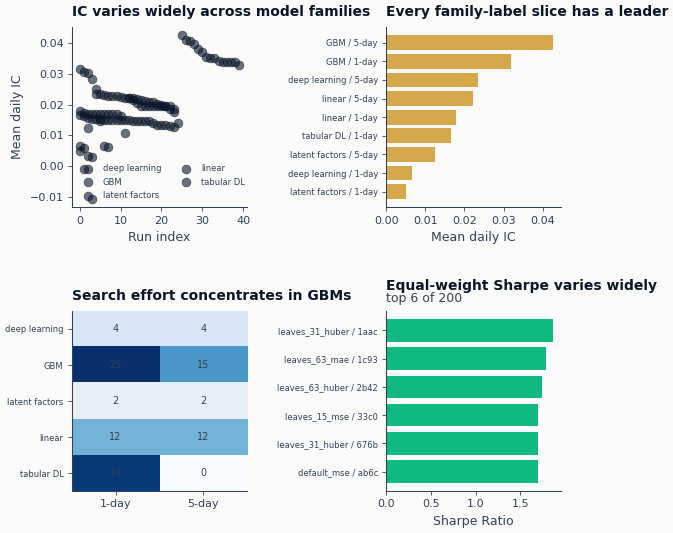

In [14]:
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE["dashboard_2x2"])
family_display = {
    "deep_learning": "deep learning",
    "latent_factors": "latent factors",
    "linear": "linear",
    "tabular_dl": "tabular DL",
    "gbm": "GBM",
}
label_display = {PRIMARY_LABEL: "1-day", SECONDARY_LABEL: "5-day"}

ax1 = axes[0, 0]
for family_name, frame in run_catalog.groupby("family"):
    ax1.scatter(
        range(len(frame)),
        frame["ic_mean"],
        alpha=0.6,
        s=40,
        label=family_display.get(family_name, family_name),
        color=COLORS.get(family_name, COLORS["blue"]),
    )
add_message_title(ax1, "IC varies widely across model families")
ax1.set_xlabel("Run index")
ax1.set_ylabel("Mean daily IC")
ax1.legend(fontsize=6, ncol=2, frameon=False)

ax2 = axes[0, 1]
leader_plot = best_validation.sort_values("ic_mean")
leader_labels = [
    f"{family_display.get(row.family, row.family)} / {label_display.get(row.label, row.label)}"
    for row in leader_plot.itertuples()
]
ax2.barh(leader_labels, leader_plot["ic_mean"], color=COLORS["amber"])
add_message_title(ax2, "Every family-label slice has a leader")
ax2.set_xlabel("Mean daily IC")
ax2.tick_params(axis="y", labelsize=6)

ax3 = axes[1, 0]
count_matrix = family_counts.pivot(index="family", columns="label", values="run_count").fillna(0)
count_matrix = count_matrix.reindex(columns=[PRIMARY_LABEL, SECONDARY_LABEL])
ax3.imshow(count_matrix, cmap="Blues", aspect="auto")
for row_idx in range(len(count_matrix.index)):
    for col_idx in range(len(count_matrix.columns)):
        value = int(count_matrix.iloc[row_idx, col_idx])
        ax3.text(col_idx, row_idx, value, ha="center", va="center", fontsize=7)
ax3.set_xticks(range(len(count_matrix.columns)), [label_display[label] for label in count_matrix])
ax3.set_yticks(
    range(len(count_matrix.index)),
    [family_display.get(family, family) for family in count_matrix.index],
)
ax3.tick_params(axis="y", labelsize=6)
add_message_title(ax3, "Search effort concentrates in GBMs")

ax4 = axes[1, 1]
if not backtest_pivot.empty and "sharpe" in backtest_pivot.columns:
    top_bt = backtest_pivot.head(6).sort_values("sharpe")
    n_bt = len(top_bt)
    n_total = len(backtest_pivot)
    labels = top_bt["config_name"] + " / " + top_bt["backtest_hash"].str[:4]
    ax4.barh(labels, top_bt["sharpe"].fillna(0), color=COLORS["positive"])
    title_suffix = f"top {n_bt} of {n_total}" if n_total > n_bt else f"n={n_bt} in registry"
    add_message_title(
        ax4,
        "Equal-weight Sharpe varies widely",
        subtitle=title_suffix,
    )
    ax4.set_xlabel("Sharpe Ratio")
    ax4.tick_params(axis="y", labelsize=6)
    if n_bt == 1:
        ax4.text(
            0.5,
            0.95,
            "Only 1 backtest tracked; the panel widens automatically as more runs land",
            ha="center",
            va="top",
            transform=ax4.transAxes,
            fontsize=8,
            color="gray",
        )
else:
    ax4.text(0.5, 0.5, "No backtest data", ha="center", va="center")
    add_message_title(ax4, "No equal-weight baseline results are available")

plt.tight_layout(h_pad=2.8, w_pad=2.4)
fig.show()

### Best validation runs

In [15]:
best_validation[["training_hash", "family", "label", "config_name", "ic_mean"]]

,training_hash,family,label,config_name,ic_mean
1,d2926e74dbdc,gbm,fwd_ret_1d,leaves_63_mae,0.031805
3,fd1096ce75fd,linear,fwd_ret_1d,ridge_a100000.0,0.017843
4,a1a3ae2edba4,tabular_dl,fwd_ret_1d,tabm_l,0.016681
0,9246513ff893,deep_learning,fwd_ret_1d,lstm_h64,0.006584
2,78aadd500268,latent_factors,fwd_ret_1d,ipca,0.004949
6,d7fd7e9bc6c1,gbm,fwd_ret_5d,leaves_63_mae,0.042646
5,019df47a49b0,deep_learning,fwd_ret_5d,nlinear,0.023348
8,5216a8c766c3,linear,fwd_ret_5d,ridge_a100000.0,0.022284
7,d86c023dd883,latent_factors,fwd_ret_5d,ipca,0.012391


**Finding**: `best_validation` reports the top configuration per `(family,
label)` slice; read the `ic_mean` column to see which family leads each
label, which is the question the registry exists to answer.

### Training run counts by family and label

In [16]:
family_counts

,label,family,run_count
0,fwd_ret_1d,deep_learning,4
1,fwd_ret_1d,gbm,25
2,fwd_ret_1d,latent_factors,2
3,fwd_ret_1d,linear,12
4,fwd_ret_1d,tabular_dl,24
5,fwd_ret_5d,deep_learning,4
6,fwd_ret_5d,gbm,15
7,fwd_ret_5d,latent_factors,2
8,fwd_ret_5d,linear,12


**Finding**: `family_counts` is the experiment-budget view — how many
configurations a given family tried per label. Heavy concentration in one
family signals where the search effort went, which the governance log needs
to make auditable.

### Selected run manifest

In [17]:
manifest

,artifact,path,exists
0,training spec,case_studies/us_equities_panel/run_log/trainin...,True
1,predictions,case_studies/us_equities_panel/run_log/predict...,True


## 7. MLflow experiment tracking

The custom registry satisfies Section 6.7's run log requirements, but it
requires bespoke SQL queries and manual catalog reconstruction. MLflow
provides a standard API — `log_params`, `log_metrics`, `log_artifact`,
`search_runs` — that automates the same workflow. This section logs the
runs from the registry into a local MLflow store and shows that the
rankings are identical.

In [18]:
import mlflow

print(f"MLflow {mlflow.__version__} available")

MLflow 3.12.0 available


### Set up a local file-backed tracking store

MLflow can write to a local directory — no server required. We use a chapter
output directory so the notebook writes to the correct location (not the
repo root).

In [19]:
import shutil

MLFLOW_DIR = get_output_dir(26, "mlflow_tracking")
# Remove any stale store from a previously interrupted run before recreating;
# otherwise search_runs can return runs from prior executions and the parity
# check would silently include phantom rows.
shutil.rmtree(MLFLOW_DIR, ignore_errors=True)
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DIR / 'mlflow.db'}")
experiment = mlflow.set_experiment(CASE_STUDY_ID)
print(f"Tracking URI : {MLFLOW_DIR}")
print(f"Experiment   : {experiment.name} (id={experiment.experiment_id})")

2026/07/22 23:04:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/07/22 23:04:51 INFO mlflow.store.db.utils: Updating database tables


2026/07/22 23:04:54 INFO mlflow.tracking.fluent: Experiment with name 'us_equities_panel' does not exist. Creating a new experiment.


Tracking URI : ~/scratch/ml4t-ch26-output/ch26_mlflow_tracking
Experiment   : us_equities_panel (id=1)


### Log catalog runs into MLflow

The capped sample always includes every `(family, label)` leader, then fills
the remaining slots with the strongest other validation runs. Parameters come
from the registry columns; mean daily validation IC is the primary metric.

In [20]:
def log_catalog_to_mlflow(catalog: pd.DataFrame, max_runs: int = 50) -> int:
    """Log catalog rows as MLflow runs. Returns the count logged.

    Caps at `max_runs` to keep the demo fast — a real pipeline would log
    incrementally as each training job completes.
    """
    logged = 0
    for row in catalog.itertuples(index=False):
        if logged >= max_runs:
            break
        ic = row.ic_mean
        if ic is None or (isinstance(ic, float) and pd.isna(ic)):
            continue

        with mlflow.start_run(run_name=row.training_hash):
            params = {"family": str(row.family), "label": str(row.label)}
            if row.config_name is not None:
                params["config_name"] = str(row.config_name)
            mlflow.log_params(params)

            metrics = {"ic_mean_daily": float(ic)}
            mlflow.log_metrics(metrics)

            spec_path = TRAINING_DIR / row.training_hash / "spec.json"
            if spec_path.exists():
                mlflow.log_artifact(str(spec_path))

        logged += 1
    return logged


leader_hashes = set(best_validation["training_hash"])
leaders = run_catalog[run_catalog["training_hash"].isin(leader_hashes)]
remaining = run_catalog[~run_catalog["training_hash"].isin(leader_hashes)].sort_values(
    "ic_mean", ascending=False
)
catalog_sample = pd.concat([leaders, remaining], ignore_index=True).head(50)
assert leader_hashes.issubset(set(catalog_sample["training_hash"]))
n_logged = log_catalog_to_mlflow(catalog_sample, max_runs=len(catalog_sample))
assert n_logged == len(catalog_sample)
print(f"Logged {n_logged} runs into MLflow experiment '{CASE_STUDY_ID}'")

Logged 50 runs into MLflow experiment 'us_equities_panel'


### Query runs with `search_runs`

`mlflow.search_runs` returns a pandas DataFrame with columns prefixed by
`params.` and `metrics.`. This is the MLflow equivalent of the manual
catalog queries in Section 3.

In [21]:
all_runs = mlflow.search_runs(
    experiment_names=[CASE_STUDY_ID],
    order_by=["metrics.ic_mean_daily DESC"],
)
print(f"Total runs tracked: {len(all_runs)}")
all_runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "params.family",
        "params.label",
        "metrics.ic_mean_daily",
    ]
].head(10)

Total runs tracked: 50


,run_id,tags.mlflow.runName,params.family,params.label,metrics.ic_mean_daily
0,e6c82076ccbe4f01adbd3a4b5312291d,d7fd7e9bc6c1,gbm,fwd_ret_5d,0.042646
1,c94d8149cf714dca83758734ea3a149f,28bf55409919,gbm,fwd_ret_5d,0.041112
2,d604c16ec2a94584bdad59d828107690,f54d13bbefa1,gbm,fwd_ret_5d,0.040688
3,439f47c8561a4a2885245edaece23fdb,e2a88a84e710,gbm,fwd_ret_5d,0.039891
4,3776e0d5fced4b739a23f6726713f9ca,da4645756472,gbm,fwd_ret_5d,0.038283
5,3249ffbb487f40de9b744506a1f13412,4606f7578323,gbm,fwd_ret_5d,0.037240
6,d2638c9552a144018cbcdf11d79331cf,5ab0d2c2bc86,gbm,fwd_ret_5d,0.035717
7,0175772bb3c94773ab9a56c4e5e1ec2d,94633abb5ffd,gbm,fwd_ret_5d,0.035092
8,647ef8e8c885439aa591484f6dca56a1,652b5fbb8744,gbm,fwd_ret_5d,0.035088
9,d43da153c4d04a7491dba006181fd845,0a36a095c66d,gbm,fwd_ret_5d,0.034191


### Filter by family — GBM runs ranked by IC

MLflow's `filter_string` parameter supports SQL-like predicates on params
and metrics, giving the same result as the grouped ranking in Section 3.

In [22]:
gbm_runs = mlflow.search_runs(
    experiment_names=[CASE_STUDY_ID],
    filter_string="params.family = 'gbm'",
    order_by=["metrics.ic_mean_daily DESC"],
)
print(f"GBM runs: {len(gbm_runs)}")
gbm_runs[
    [
        "tags.mlflow.runName",
        "params.label",
        "params.config_name",
        "metrics.ic_mean_daily",
    ]
].head(10)

GBM runs: 34


,tags.mlflow.runName,params.label,params.config_name,metrics.ic_mean_daily
0,d7fd7e9bc6c1,fwd_ret_5d,leaves_63_mae,0.042646
1,28bf55409919,fwd_ret_5d,leaves_31_mae,0.041112
2,f54d13bbefa1,fwd_ret_5d,default_mae,0.040688
3,e2a88a84e710,fwd_ret_5d,leaves_15_mae,0.039891
4,da4645756472,fwd_ret_5d,leaves_7_mae,0.038283
5,4606f7578323,fwd_ret_5d,leaves_63_huber,0.037240
6,5ab0d2c2bc86,fwd_ret_5d,leaves_31_huber,0.035717
7,94633abb5ffd,fwd_ret_5d,leaves_15_huber,0.035092
8,652b5fbb8744,fwd_ret_5d,leaves_63_mse,0.035088
9,0a36a095c66d,fwd_ret_5d,leaves_7_huber,0.034191


### Verify ranking parity with the manual catalog

The whole point: MLflow's `search_runs` ordering must match the manual
catalog from Section 3. We compare the top run per family × label group.
The capped sample includes every group leader by construction, so parity must
cover the complete set rather than only the leaders that happen to rank in the
global top 50.

In [23]:
mlflow_best = (
    all_runs.sort_values("metrics.ic_mean_daily", ascending=False)
    .groupby(["params.label", "params.family"], as_index=False)
    .first()
)
mlflow_best_compact = mlflow_best.rename(
    columns={
        "tags.mlflow.runName": "training_hash",
        "params.family": "family",
        "params.label": "label",
        "metrics.ic_mean_daily": "ic_mean",
    }
)[["training_hash", "family", "label", "ic_mean"]].sort_values(
    ["label", "ic_mean"], ascending=[True, False]
)

manual_best_compact = best_validation[["training_hash", "family", "label", "ic_mean"]].sort_values(
    ["label", "ic_mean"], ascending=[True, False]
)

comparison = mlflow_best_compact.merge(
    manual_best_compact,
    on=["family", "label"],
    how="outer",
    suffixes=("_mlflow", "_manual"),
    indicator=True,
)
comparison["ic_match"] = (comparison["ic_mean_mlflow"] - comparison["ic_mean_manual"]).abs() < 1e-8
comparison["hash_match"] = comparison["training_hash_mlflow"] == comparison["training_hash_manual"]
assert (comparison["_merge"] == "both").all()
assert comparison[["ic_match", "hash_match"]].all().all()
print("Ranking parity check (MLflow vs manual catalog):")
comparison

Ranking parity check (MLflow vs manual catalog):


,training_hash_mlflow,family,label,ic_mean_mlflow,training_hash_manual,ic_mean_manual,_merge,ic_match,hash_match
0,9246513ff893,deep_learning,fwd_ret_1d,0.006584,9246513ff893,0.006584,both,True,True
1,019df47a49b0,deep_learning,fwd_ret_5d,0.023348,019df47a49b0,0.023348,both,True,True
2,d2926e74dbdc,gbm,fwd_ret_1d,0.031805,d2926e74dbdc,0.031805,both,True,True
3,d7fd7e9bc6c1,gbm,fwd_ret_5d,0.042646,d7fd7e9bc6c1,0.042646,both,True,True
4,78aadd500268,latent_factors,fwd_ret_1d,0.004949,78aadd500268,0.004949,both,True,True
5,d86c023dd883,latent_factors,fwd_ret_5d,0.012391,d86c023dd883,0.012391,both,True,True
6,fd1096ce75fd,linear,fwd_ret_1d,0.017843,fd1096ce75fd,0.017843,both,True,True
7,5216a8c766c3,linear,fwd_ret_5d,0.022284,5216a8c766c3,0.022284,both,True,True
8,a1a3ae2edba4,tabular_dl,fwd_ret_1d,0.016681,a1a3ae2edba4,0.016681,both,True,True


**Finding**: The capped sample contains every group leader, and the outer
parity check proves that MLflow and the registry agree on both leader identity
and mean daily validation IC for every `(family, label)` slice.

### Clean up

Remove the tracking store. In production, the tracking store would persist —
either as a file directory or a remote server.

In [24]:
shutil.rmtree(MLFLOW_DIR, ignore_errors=True)
print(f"Cleaned up tracking store: {MLFLOW_DIR}")

Cleaned up tracking store: ~/scratch/ml4t-ch26-output/ch26_mlflow_tracking


## Key Takeaways

1. The run log requirements from §6.7 — provenance, configuration, artifacts, metrics, and decision gates — are what make experiment tracking useful. The case-study registry implements them with SQLite + content-addressed bundles; MLflow implements them with a standard API and query interface.
2. Both systems produce identical rankings on the same catalog because the governance value comes from the underlying discipline (deterministic hashing, reproducibility manifests, promotion gates), not the specific tool.
3. Start with a simple registry while a team is small; migrate to MLflow, Weights & Biases, or Neptune when multi-user collaboration, a web UI, or CI/CD integration becomes load-bearing.

**Next**: This is the final notebook of Chapter 26. The chapter prose closes
with the three-layer governance model — detection, response, automated
safety — which together with the supporting MLOps stack keep deployed
strategies auditable.